In [1]:
from corrqec2.experiments import SurfaceCodeMemory

In [2]:
experiment = SurfaceCodeMemory(distance=3, rounds='3d', memory_type='Z')
experiment.gen_stim_circuit()

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    I 1 3 5 8 10 12 15 17 19
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 25
    TICK
    MR 2 9 11 13 14 16 18 25
    DETECTOR(0, 4, 0) rec[-4]
    DETECTOR(2, 2, 0) rec[-7]
    DETECTOR(4, 4, 0) rec[-2]
    DETECTOR(6, 2, 0) rec[-5]
    REPEAT 8 {
        TICK
        I 1 3 5 8 10 12 15 17 19
    

In [3]:
experiment.all_qubit_coords

{1: [1.0, 1.0],
 2: [2.0, 0.0],
 3: [3.0, 1.0],
 5: [5.0, 1.0],
 8: [1.0, 3.0],
 9: [2.0, 2.0],
 10: [3.0, 3.0],
 11: [4.0, 2.0],
 12: [5.0, 3.0],
 13: [6.0, 2.0],
 14: [0.0, 4.0],
 15: [1.0, 5.0],
 16: [2.0, 4.0],
 17: [3.0, 5.0],
 18: [4.0, 4.0],
 19: [5.0, 5.0],
 25: [4.0, 6.0]}

In [4]:
experiment.qubit_coords

{'data': {1: [1.0, 1.0],
  3: [3.0, 1.0],
  5: [5.0, 1.0],
  8: [1.0, 3.0],
  10: [3.0, 3.0],
  12: [5.0, 3.0],
  15: [1.0, 5.0],
  17: [3.0, 5.0],
  19: [5.0, 5.0]},
 'syndrome': {2: [2.0, 0.0],
  9: [2.0, 2.0],
  11: [4.0, 2.0],
  13: [6.0, 2.0],
  14: [0.0, 4.0],
  16: [2.0, 4.0],
  18: [4.0, 4.0],
  25: [4.0, 6.0]}}

In [5]:
experiment.qubits

{'data': [1, 3, 5, 8, 10, 12, 15, 17, 19],
 'syndrome': [2, 9, 11, 13, 14, 16, 18, 25]}

In [6]:
experiment.all_qubit_types

['data', 'syndrome']

In [7]:
experiment.get_qubits_by_type('syndrome')

[2, 9, 11, 13, 14, 16, 18, 25]

In [8]:
experiment.error_matrix_shape(('all'))

(17, 9)

### Storm Model Test

In [9]:
from corrqec2.noisemodels import Storm
from corrqec2.experiments import SurfaceCodeMemory

experiment = SurfaceCodeMemory(distance=3, rounds='3d', memory_type='Z')

In [10]:
a = 0.01
b = 0.1
emissions = [[1., 0., 0., 0.], [0.25, 0.25, 0.25, 0.25]]

model_params = {
    'a': a,
    'b': b,
    'emissions': emissions,
}
p = 0.01
# gate_noise = {
#     #'after_identity_depolarization': p,
#     'after_clifford_depolarization': p,
#     'before_measure_flip_probability': p,
#     #'after_reset_flip_probability': p,
# }
gate_noise = None
noisy_qubit_types = 'all'
model = Storm(model_params=model_params, gate_noise=gate_noise, noisy_qubit_types=noisy_qubit_types)

In [11]:
results = model.gen_error_matrix(experiment, n_samples=1000)

In [12]:
# from corrqec2.noisemodels import Storm
# from corrqec2.experiments.surface_code_memory import SurfaceCodeMemory
# import os, time
# import jax, jax.profiler

# experiment = SurfaceCodeMemory(distance=9, rounds='1000d', memory_type='Z')

# model_params = {
#     'a': 0.01,
#     'b': 0.1,
#     'emissions': [[1., 0., 0., 0.], [0.25, 0.25, 0.25, 0.25]],
# }
# model = Storm(model_params=model_params)  # uses JAX ops under the hood :contentReference[oaicite:0]{index=0}

# LOGDIR = "/home/fidel/Projects/corr-qec2/notebooks/jax_profile"
# os.makedirs(LOGDIR, exist_ok=True)

# # --- Warm up JIT (so compilation isn't mixed into the profile unless you want it) ---
# warm = model.gen_error_matrix(experiment, n_samples=32)  # smaller warmup
# _ = warm.block_until_ready()

# # --- Start trace ---
# jax.profiler.start_trace(LOGDIR)

# for i in range(10):
#     with jax.profiler.StepTraceAnnotation("storm_sampling", step_num=i):
#         samples = model.gen_error_matrix(experiment, n_samples=1)
#         _ = samples.block_until_ready()     # <-- CRITICAL: synchronize so kernels finish
#         time.sleep(0.05)                    # small gap makes the timeline clearer

# jax.profiler.stop_trace()
# print("Trace written to:", LOGDIR)


In [13]:
# %load_ext tensorboard
# %tensorboard --logdir /home/fidel/Projects/corr-qec2/notebooks/jax_profile

Test sampling

In [14]:
from corrqec2 import Sampler

sampler = Sampler(experiment, model, batch_size=100)

In [15]:
sampler._sample_batch()[1]

array([False,  True,  True, False,  True, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False,  True, False, False, False, False,  True,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False,  True, False,
       False,  True, False, False, False, False, False,  True, False,
        True, False,  True, False, False, False, False, False, False,
        True,  True, False, False,  True, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False])

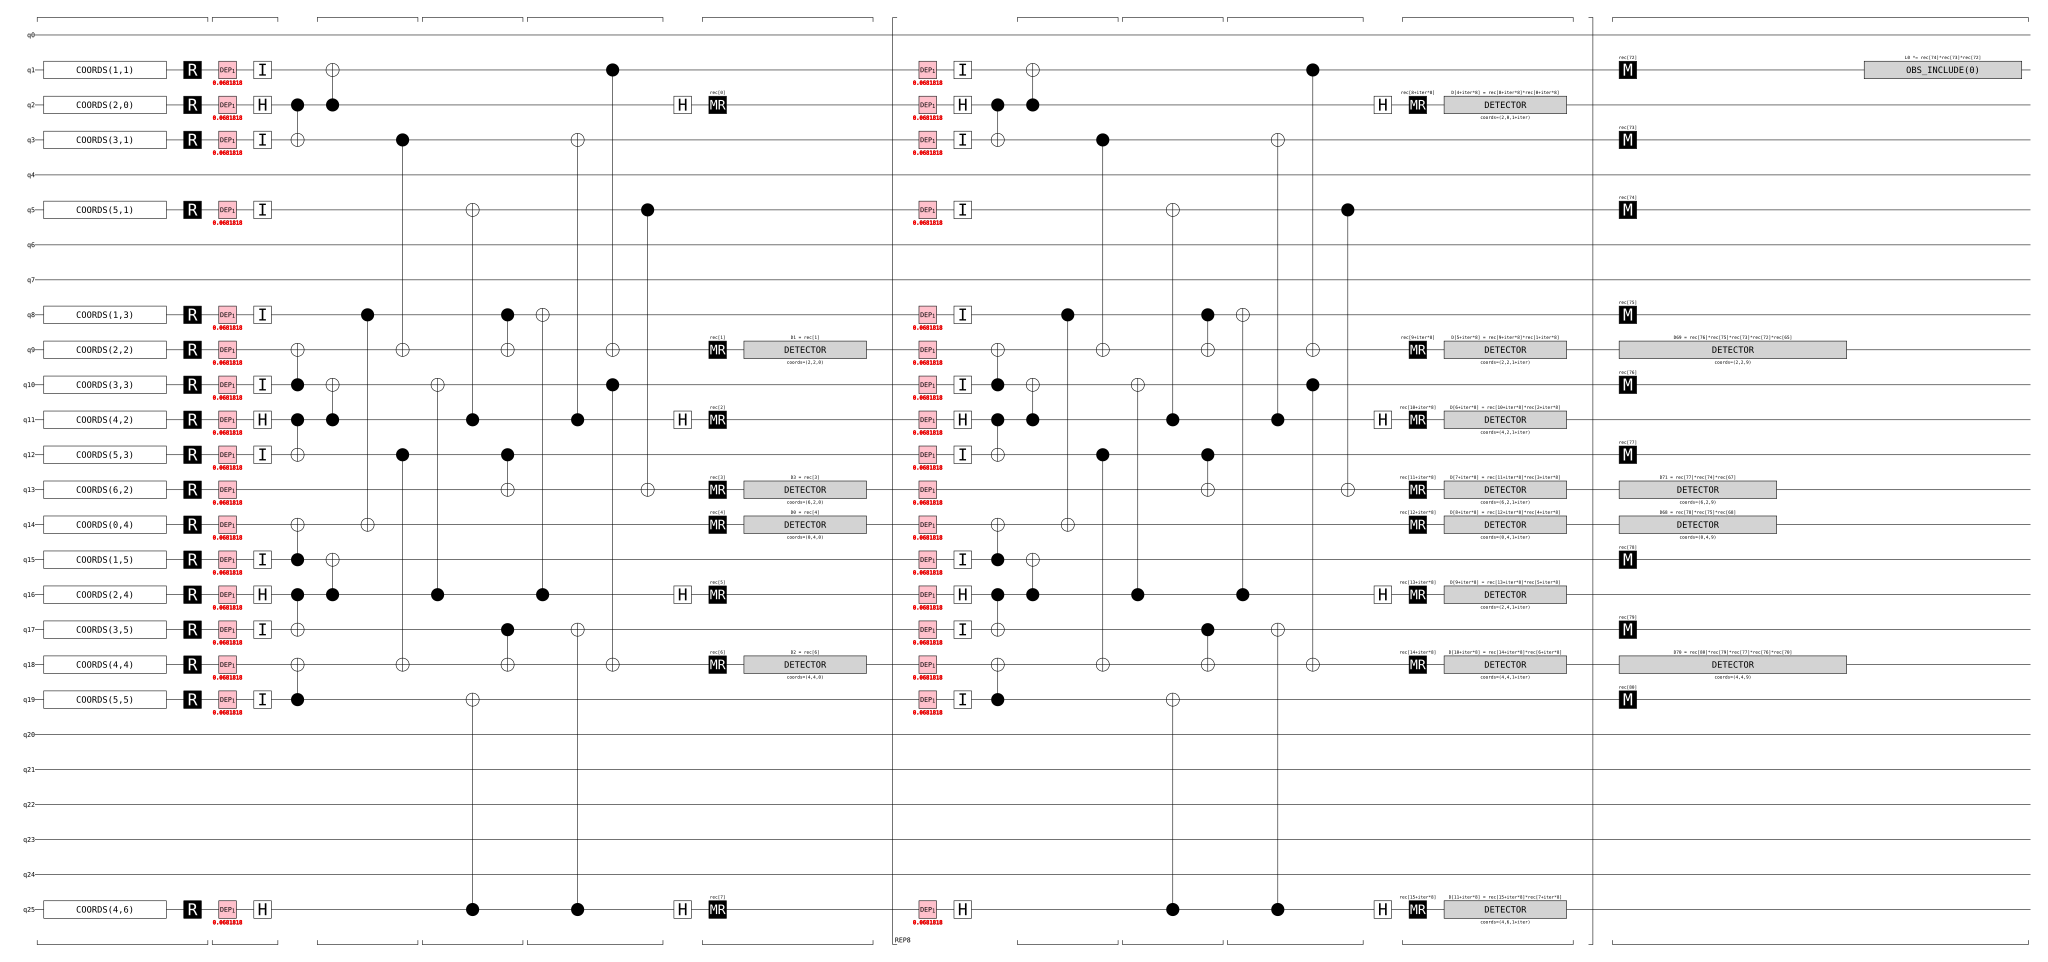

In [17]:
model.gen_marginalized_circuit(experiment).diagram('timeline-svg')